In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [29]:

raw = load_iris()

df = pd.DataFrame(data=raw.data, columns=raw.feature_names)
df['species'] = pd.Categorical.from_codes(raw.target, raw.target_names)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
df.head(10)

Dataset loaded successfully.
Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [30]:


print("Data Types & Non-Null Counts:")
print(df.info())

print("\nNull Value Check:")
print(df.isnull().sum())


print("\n Class Distribution:")
print(df['species'].value_counts())


Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None

Null Value Check:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

 Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [32]:
print(" Descriptive Statistics:")
df.describe()

 Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


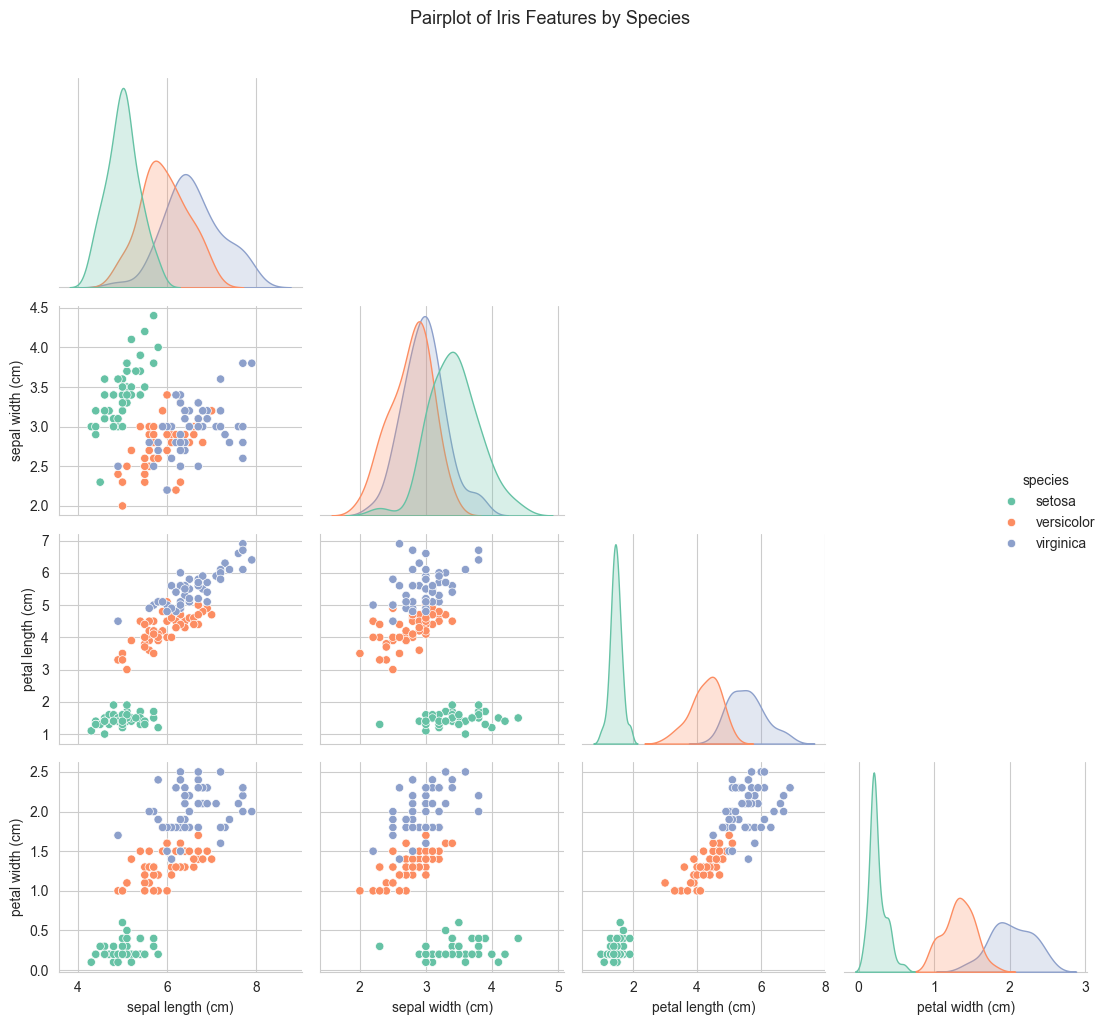

In [35]:
#Pairplot
sns.pairplot(df, hue='species', palette='Set2', corner=True)
plt.suptitle("Pairplot of Iris Features by Species", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("pairplot.png", dpi=150, bbox_inches='tight')
plt.show()



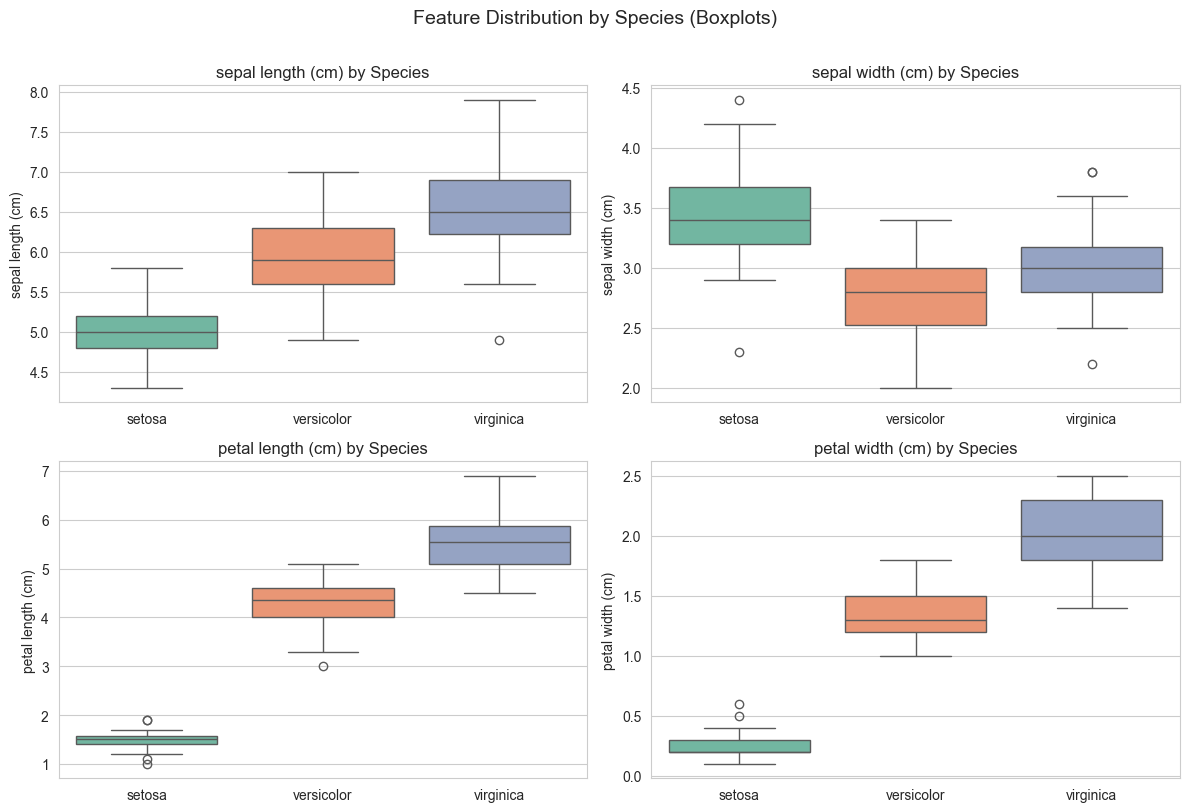

In [36]:
# Boxplots 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = raw.feature_names

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='species', y=feature, palette='Set2', ax=ax)
    ax.set_title(f'{feature} by Species')
    ax.set_xlabel('')

plt.suptitle("Feature Distribution by Species (Boxplots)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

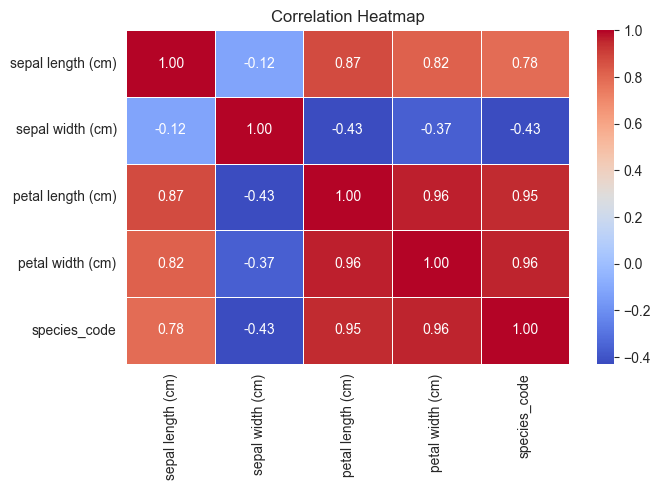


Feature Analysis:
-----------------
- petal length (cm) → highest correlation with species (0.95)
- petal width (cm)  → second most discriminative (0.96)
- sepal length (cm) → moderate correlation (~0.78)
- sepal width (cm)  → least discriminative, slightly negative correlation

Conclusion: Petal features (length & width) are the most useful for classification.
All 4 features will still be used since they collectively improve model accuracy.



In [8]:
df_encoded = df.copy()
df_encoded['species_code'] = raw.target

corr = df_encoded.drop(columns=['species']).corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("""
Feature Analysis:
-----------------
- petal length (cm) → highest correlation with species (0.95)
- petal width (cm)  → second most discriminative (0.96)
- sepal length (cm) → moderate correlation (~0.78)
- sepal width (cm)  → least discriminative, slightly negative correlation

Conclusion: Petal features (length & width) are the most useful for classification.
All 4 features will still be used since they collectively improve model accuracy.
""")

In [20]:

X = df[raw.feature_names]
y = raw.target   # 0=setosa, 1=versicolor, 2=virginica

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Train class dist : {np.bincount(y_train)}")
print(f"Test class dist  : {np.bincount(y_test)}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  
X_test_sc  = scaler.transform(X_test)

Training samples : 120
Testing samples  : 30
Train class dist : [40 40 40]
Test class dist  : [10 10 10]


In [21]:

models = {
    "Logistic Regression" : LogisticRegression(max_iter=200, random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree"       : DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42)
}


results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "K-Nearest Neighbours"]:
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc}
    print(f"{name:25s} → Accuracy: {acc * 100:.2f}%")

Logistic Regression       → Accuracy: 93.33%
K-Nearest Neighbours      → Accuracy: 93.33%
Decision Tree             → Accuracy: 93.33%
Random Forest             → Accuracy: 90.00%


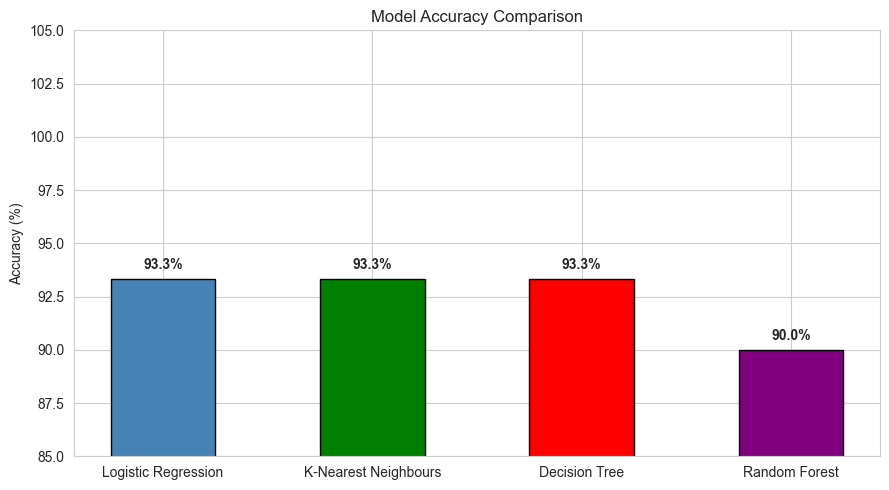

In [37]:
names = list(results.keys())
accuracies = [results[n]["accuracy"] * 100 for n in names]

colors = ['steelblue', 'green', 'red', 'purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylim(85, 105)
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{acc:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

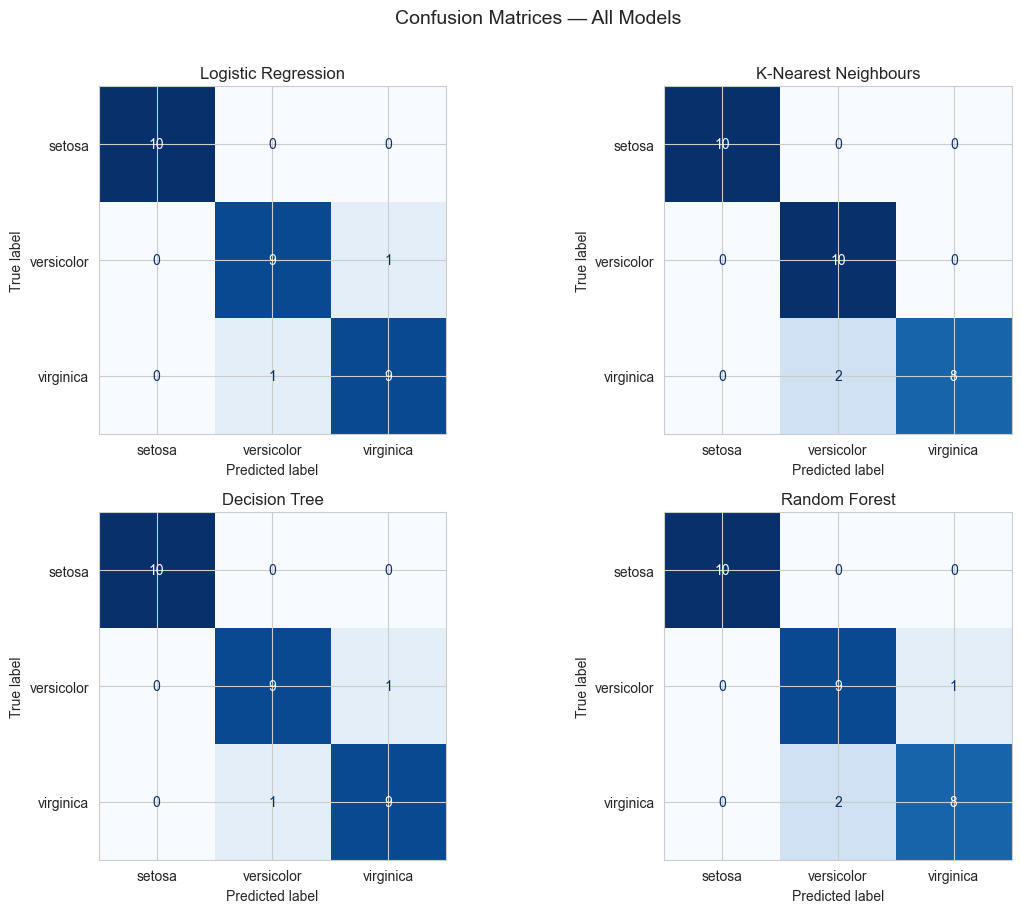

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=raw.target_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

In [38]:
for name, res in results.items():
    print(f"  {name}")
    print(classification_report(y_test, res["preds"], target_names=raw.target_names))

  Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

  K-Nearest Neighbours
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

  Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica  

In [39]:
# Finding the best model based on test accuracy
best_name = max(results, key=lambda n: results[n]["accuracy"])
best_acc  = results[best_name]["accuracy"]

print(f"""
  Best Performing Model: {best_name}
  Test Accuracy        : {best_acc * 100:.2f}%
""")


  Best Performing Model: Logistic Regression
  Test Accuracy        : 93.33%



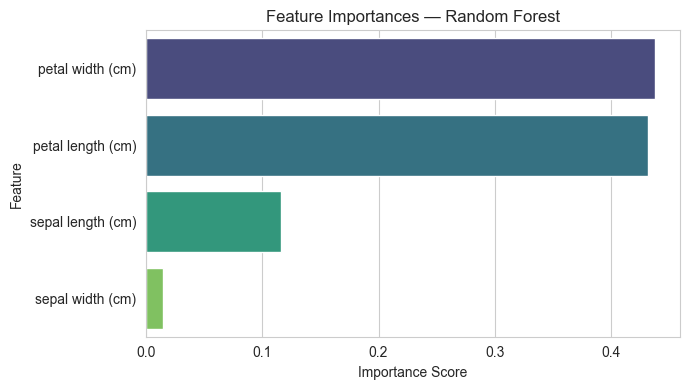

          Feature  Importance
 petal width (cm)    0.437185
petal length (cm)    0.431466
sepal length (cm)    0.116349
 sepal width (cm)    0.015000


In [26]:


rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
feat_names  = raw.feature_names

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

print(feat_df.to_string(index=False))


In [28]:

sample = np.array([[5.1, 3.5, 1.4, 0.2]])  

sample_sc = scaler.transform(sample)
pred = results["Random Forest"]["model"].predict(sample)

print(f"Input measurements : sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2")
print(f"Predicted species  : {raw.target_names[pred[0]].upper()}")

Input measurements : sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2
Predicted species  : SETOSA
